In [18]:
%load_ext autoreload
%autoreload 2

import torch
from ncpu.dashboard import nca_dashboard
from ncpu.trainer import NCPUTrainer
import mediapy as media

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
def print_tensor(title, t):
    shape = tuple(t.shape)
    print(
        f"{title}: {shape} {t.dtype}, min={t.min():.2f}, max={t.max():.2f}, mean={t.mean():.2f}, std={t.std():.2f}"
    )

In [6]:
trainer = NCPUTrainer.get_default_trainer()

Sanity check...
  forward: torch.Size([2, 16, 117, 117]) -> torch.Size([2, 11, 16, 117, 117])
  dataloader: torch.Size([16, 117, 117]) -> torch.Size([16, 117, 117])
  first_state: torch.Size([16, 16, 117, 117])
  rollout: torch.Size([16, 11, 16, 117, 117])
  loss: 0.3017979860305786
Sanity check completed successfully


In [12]:
!ls

makefile  notebooks  pyproject.toml  README.md	src  uv.lock


In [14]:
state_dict = torch.load("notebooks/checkpoints/ncpu_127580_20251130_203719.pth")
trainer.nca.load_state_dict(state_dict)

<All keys matched successfully>

In [15]:
from ncpu.utils import sequence_batch_to_html_gifs

loss=0.076967:  81%|########  | 161499/200000 [4:27:30<59:41, 10.75it/s]

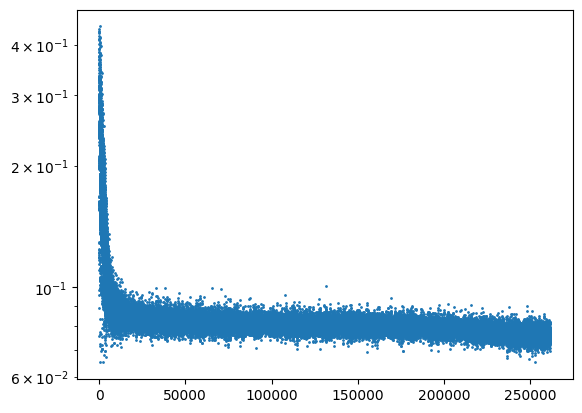

inp    : (16, 117, 117) torch.float32, min=0.00, max=1.00, mean=0.14, std=0.35
out    : (16, 117, 117) torch.float32, min=0.00, max=1.00, mean=0.02, std=0.13
nca_out: (16, 117, 117) torch.float32, min=-0.31, max=1.00, mean=0.10, std=0.26


,,,,,,,
,,,,,,,
,,,,,,,

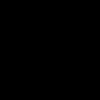
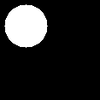
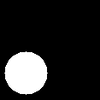
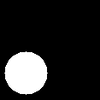
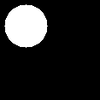
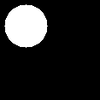
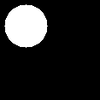
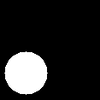
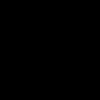
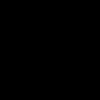
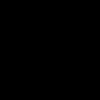
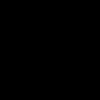
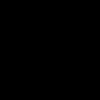
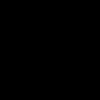
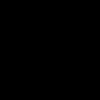
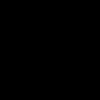
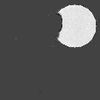
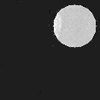
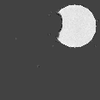
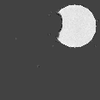
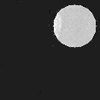
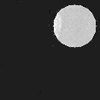
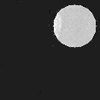
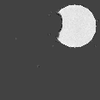

In [ ]:
from matplotlib import pyplot as plt
from IPython.display import clear_output, display
from tqdm.auto import tqdm
from datetime import datetime

pbar = tqdm(range(200_000))
for i in pbar:
    info = trainer.optim_step(steps=20)
    loss = info["loss"].item()
    pbar.set_description(f"loss={loss:.6f}")

    if i % 250 == 0:
        clear_output(wait=False)
        display(pbar.container)
        plt.scatter(range(len(trainer.history)), trainer.history, s=1)
        plt.yscale("log")
        plt.show()

        print_tensor("inp    ", info["inp"])
        print_tensor("out    ", info["out"])
        print_tensor("nca_out", info["nca_out"])

        to_show = 8
        inp = info["inp"][:to_show]
        out = info["out"][:to_show]
        nca_out = info["nca_out"][:to_show]
        rollout = info["rollout"][:to_show]
        io = torch.cat([inp, out, nca_out], dim=0)

        media.show_images(io.detach().cpu(), columns=to_show, width=100, height=100)
        sequence_batch_to_html_gifs(rollout, columns=to_show, fps=10)

        it = len(trainer.history)
        path = f"notebooks/checkpoints/ncpu_{it}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth"
        torch.save(trainer.nca.state_dict(), path)

In [ ]:
1